<a href="https://colab.research.google.com/github/dinanrzki/My-Journey/blob/main/Tugas_5_Komputasi_dan_Pemrograman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          METODE SECANT: Mencari akar 3x - e^x = 0
  Titik awal : x0 = 0.0, x1 = 1.0
  Toleransi  : 1e-05
Iter |       x(n-1) |         x(n) |    f(x(n-1)) |      f(x(n)) |       x(n+1) |      Error
-------------------------------------------------------------------------------------
   1 |   0.00000000 |   1.00000000 |  -1.00000000 |   0.28171817 |   0.78020272 |   2.20e-01
   2 |   1.00000000 |   0.78020272 |   0.28171817 |   0.15869362 |   0.49667861 |   2.84e-01
   3 |   0.78020272 |   0.49667861 |   0.15869362 |  -0.15321848 |   0.63595225 |   1.39e-01
   4 |   0.49667861 |   0.63595225 |  -0.15321848 |   0.01903683 |   0.62056039 |   1.54e-02
   5 |   0.63595225 |   0.62056039 |   0.01903683 |   0.00171111 |   0.61904027 |   1.52e-03
   6 |   0.62056039 |   0.61904027 |   0.00171111 |  -0.00002402 |   0.61906131 |   2.10e-05
   7 |   0.61904027 |   0.61906131 |  -0.00002402 |   0.00000003 |   0.61906129 |   2.56e-08
----------------------------------------------------------------

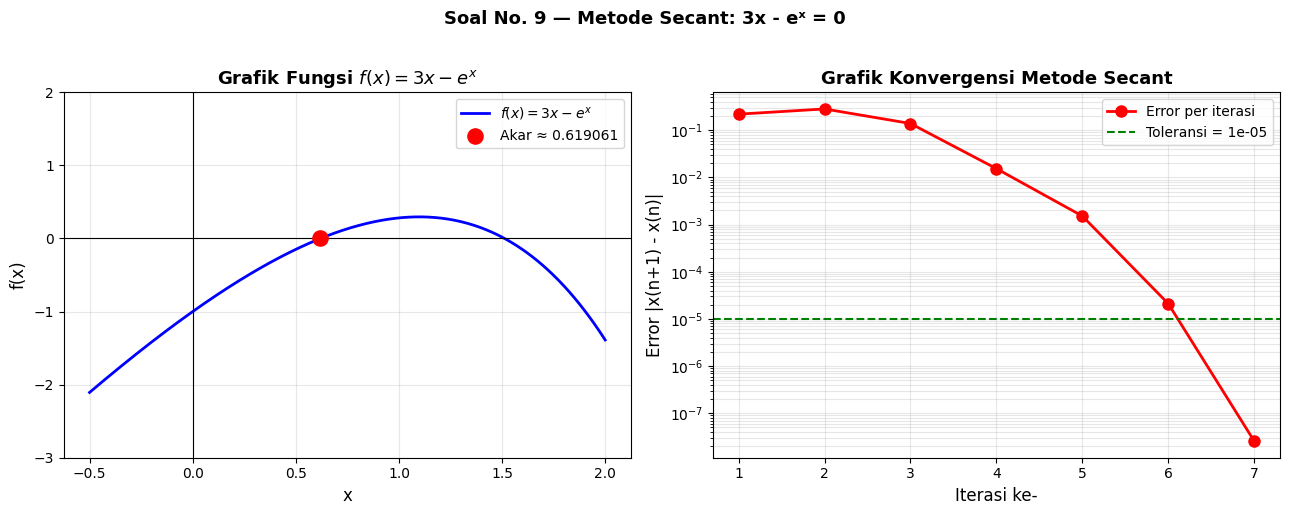


Grafik disimpan sebagai: hasil_metode_secant.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#   SOAL NO. 9 - METODE SECANT
#   Persamaan : 3x - e^x = 0
#   Titik awal: x0 = 0.0, x1 = 1.0
#   Toleransi : 1e-5
# ============================================================

def f(x):
    """Fungsi persamaan: f(x) = 3x - e^x"""
    return 3*x - np.exp(x)

def secant_method(x0, x1, tol=1e-5, max_iter=100):
    """
    Metode Secant untuk mencari akar f(x) = 0

    Parameter:
        x0, x1   : dua titik awal
        tol      : toleransi galat
        max_iter : maksimum iterasi

    Return:
        x2   : aproksimasi akar
        data : list hasil tiap iterasi
    """
    data = []
    f0 = f(x0)
    f1 = f(x1)

    print("=" * 70)
    print("          METODE SECANT: Mencari akar 3x - e^x = 0")
    print("=" * 70)
    print(f"  Titik awal : x0 = {x0}, x1 = {x1}")
    print(f"  Toleransi  : {tol}")
    print("=" * 70)
    print(f"{'Iter':>4} | {'x(n-1)':>12} | {'x(n)':>12} | {'f(x(n-1))':>12} | {'f(x(n))':>12} | {'x(n+1)':>12} | {'Error':>10}")
    print("-" * 85)

    for i in range(1, max_iter + 1):
        # Cek pembagi nol
        if abs(f1 - f0) < 1e-15:
            print("Pembagi mendekati nol, iterasi dihentikan.")
            break

        # Formula Secant
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        error = abs(x2 - x1)
        f2 = f(x2)

        print(f"{i:>4} | {x0:>12.8f} | {x1:>12.8f} | {f0:>12.8f} | {f1:>12.8f} | {x2:>12.8f} | {error:>10.2e}")

        data.append({
            'iter': i, 'x0': x0, 'x1': x1,
            'f0': f0, 'f1': f1, 'x2': x2, 'error': error
        })

        # Cek konvergensi
        if error < tol:
            print("-" * 85)
            print(f"\n  ✅ KONVERGEN setelah {i} iterasi!")
            break

        # Update untuk iterasi berikutnya
        x0, f0 = x1, f1
        x1, f1 = x2, f2

    return x2, data


# ---- JALANKAN PROGRAM ----
x0  = 0.0
x1  = 1.0
tol = 1e-5

root, data = secant_method(x0, x1, tol)

print(f"\n  Akar yang ditemukan : x  = {root:.8f}")
print(f"  Verifikasi          : f(x) = {f(root):.2e}  (≈ 0 ✅)")
print("=" * 70)


# ---- VISUALISASI ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafik fungsi
x_plot = np.linspace(-0.5, 2, 400)
axes[0].plot(x_plot, f(x_plot), 'b-', linewidth=2, label=r'$f(x) = 3x - e^x$')
axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].scatter([root], [f(root)], color='red', s=120, zorder=5,
                label=f'Akar ≈ {root:.6f}')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('f(x)', fontsize=12)
axes[0].set_title(r'Grafik Fungsi $f(x) = 3x - e^x$', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-3, 2)

# Grafik konvergensi error
iters  = [d['iter'] for d in data]
errors = [d['error'] for d in data]
axes[1].semilogy(iters, errors, 'ro-', linewidth=2, markersize=8, label='Error per iterasi')
axes[1].axhline(tol, color='green', linestyle='--', linewidth=1.5, label=f'Toleransi = {tol}')
axes[1].set_xlabel('Iterasi ke-', fontsize=12)
axes[1].set_ylabel('Error |x(n+1) - x(n)|', fontsize=12)
axes[1].set_title('Grafik Konvergensi Metode Secant', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Soal No. 9 — Metode Secant: 3x - eˣ = 0', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hasil_metode_secant.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan sebagai: hasil_metode_secant.png")